# Flight Delays

[Project extensions are at the bottom of this file]

Millions of people fly every day, and flight delays can be an unwelcome aspect of air travel. Just how often do flight delays occur?

In this project, you will work with airport flight data and explore how the day of week affects the likelihood of a delayed departure.

### Loading the Data
The `'atlanta-airport-flights-2023.csv'` file contains a sample of domestic flights going out of the world's busiest airport. Load up the data and take a look.

Activity Goals:
- Import libraries.
- Load the flight delay data.
- Display the dataframe.

In [48]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'flights.csv'.

# from google.colab import files
# uploaded = files.upload()

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
flights = pd.read_csv('flights.csv')
flights = flights.convert_dtypes()
pd.options.mode.chained_assignment = None  
flights


,scheduled,actual,carrier,flight,tailnum,origin,dest,air_time,distance
0,"04/29/2023, 16:35","04/29/2023, 17:01",WN,1079,N230WN,ATL,HOU,110,696
1,"07/02/2023, 15:10","07/02/2023, 15:05",DL,355,N953AT,ATL,GPT,54,352
2,"12/25/2023, 10:55","12/25/2023, 10:53",WN,291,N413WN,ATL,RDU,57,356
3,"09/01/2023, 12:50","09/01/2023, 12:48",DL,1132,N947DZ,ATL,TYS,28,152
4,"12/14/2023, 07:05","12/14/2023, 07:02",DL,40,N332DN,ATL,BOS,121,946
...,...,...,...,...,...,...,...,...,...
4995,"11/15/2023, 14:20","11/15/2023, 14:17",WN,13,N400WN,ATL,MCO,63,404
4996,"04/09/2023, 19:50","04/09/2023, 19:58",OH,1320,N567NN,ATL,CLT,42,226
4997,"12/14/2023, 13:20","12/14/2023, 13:16",DL,695,N363NB,ATL,DAL,103,721
4998,"12/06/2023, 13:05","12/06/2023, 13:01",DL,911,N992AT,ATL,GSO,56,306


The `scheduled` column represents the time the flight was scheduled, but the actual departure time is represented by the `actual` column. null We can use these columns to calculate flight delays.
Let's begin by extracting the two departure time columns.

Activity Goals:
- Extract `scheduled` and `actual` columns.
- Assign to new dataframe and name it departures.
- Display the results

In [56]:
departures = flights[['scheduled', 'actual']]
departures #display the dataframe

,scheduled,actual
0,"04/29/2023, 16:35","04/29/2023, 17:01"
1,"07/02/2023, 15:10","07/02/2023, 15:05"
2,"12/25/2023, 10:55","12/25/2023, 10:53"
3,"09/01/2023, 12:50","09/01/2023, 12:48"
4,"12/14/2023, 07:05","12/14/2023, 07:02"
...,...,...
4995,"11/15/2023, 14:20","11/15/2023, 14:17"
4996,"04/09/2023, 19:50","04/09/2023, 19:58"
4997,"12/14/2023, 13:20","12/14/2023, 13:16"
4998,"12/06/2023, 13:05","12/06/2023, 13:01"


What data types are being used for these departure times? Let's find out using the `info()` method. Run the code below.

In [57]:

departures.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   scheduled  5000 non-null   string
 1   actual     5000 non-null   string
dtypes: string(2)
memory usage: 78.3 KB


The time values are currently strings.

Strings are not well suited for numerical calculations. For calculations that involves dates and times, we recommend converting those strings to datetime objects.

### Convert strings to datetime

Pandas has a `to_datetime()` method that converts strings to datetime objects.

Activity Goals:
- Convert strings to datetime objects.
- Do this for both columns
- Display the updated dataframe.

In [58]:
departures['scheduled'] = pd.to_datetime(departures['scheduled'])
departures['actual'] = pd.to_datetime(departures['actual'])
departures #display

,scheduled,actual
0,2023-04-29 16:35:00,2023-04-29 17:01:00
1,2023-07-02 15:10:00,2023-07-02 15:05:00
2,2023-12-25 10:55:00,2023-12-25 10:53:00
3,2023-09-01 12:50:00,2023-09-01 12:48:00
4,2023-12-14 07:05:00,2023-12-14 07:02:00
...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00
4996,2023-04-09 19:50:00,2023-04-09 19:58:00
4997,2023-12-14 13:20:00,2023-12-14 13:16:00
4998,2023-12-06 13:05:00,2023-12-06 13:01:00


We can see there has been a slight formatting change.

Let's use `info()` to confirm the new data type. Run the code below.

In [59]:
departures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   scheduled  5000 non-null   datetime64[ns]
 1   actual     5000 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 78.3 KB


Looks good! We now have datetime values that we can use to perform date and time calculations with.

# Calculate the delays

To identify the delayed flights, let's first calculate the amount of delay for each flight using our datetime columns. The equation for the amount of flight delay is:

`delay = actual − scheduled`

Activity Goals:
- Calculate the amount of delay using eval().
- Assign the result to a new column.
- Display the dataframe.

In [60]:
departures['delay'] = departures.eval('actual - scheduled')
departures #display

ValueError: unknown type timedelta64[ns]

We have a new `delay` column! The first flight in our dataframe left 26 minutes late. The second flight has a negative delay, indicating that it left 5 minutes early.

Airlines can leave a few minutes behind schedule without being considered late. Typically a flight is considered late if it departs more than 900 seconds (15 minutes) after the scheduled departure time.

Let's determine which flights are late using `dt.total_seconds()`.

Activity Goals:
- Create a new column to flag flights as late.
- Display the dataframe.

In [61]:
departures['is_late'] = departures['delay'].dt.total_seconds() > 900
departures # display dataframe

KeyError: 'delay'

We now know which flights were delayed. Next up, calculating the day of week for each flight.

### Get the day of the week
In addition to supporting calculations, datetime objects allow us to get information such as the year, month, and day.

To do this, we take each datetime object and convert it to a formatted string using the string format time method, `strftime()`. The method uses format codes to represent the date and time. Below are a few examples:

`%d` - Day of the month as a zero-padded decimal number <br>
`%m` - Month as a zero-padded decimal number <br>
`%Y` - Year with century as a decimal number <br>

Activity Goals:
- Get the abbreviated weekday name for each flight.
- Assign the result to a new column.
- Display the dataframe.

In [ ]:
departures['day_name'] = departures['actual'].dt.strftime('%a')
departures #display
departures.to_csv('departures-check-point.tsv', index=False, sep='\t')

Each abbreviated day of the week is composed of three letters.

Now that we have the days of the week, let's calculate the percentage of flights that are delayed for each day of the week.

### Percentage flights delayed by day of week

To calculate the percentage of flights that are delayed, let's take the `mean()` of the `is_late` column for each day of the week. The mean of a True/False column equals the proportion of True values, as shown here.

We will then convert this proportion to a percentage by multiplying by 100.

Activity Goals:
- Group dataframe by day of the week.
- Calculate the mean of the 'is_late' column for each day.
- Convert that proportion to a percentage.
- Display the resulting series.

In [ ]:
proportion_delayed = departures.groupby('day_name')['is_late'].mean()
percent_delayed = proportion_delayed * 100
percent_delayed #Display series

KeyError: 'Column not found: is_late'

The index for the series is day_name. null Notice the series is ordered by the index alphabetically. From this we can see that the day with the highest percentage of delays is Sunday.

These differences will be easier to see in a graph, so let's create a bar chart.

### Plot the data
We are almost there! The percent_delayed series is ordered alphabetically. To plot the data, let's first reorder percent_delayed in natural day of the week order (Sun-Sat).

Run the code below, which uses the `reindex( )` method.

In [ ]:
new_index_order = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
percent_delayed = percent_delayed.reindex(new_index_order)
percent_delayed

NameError: name 'percent_delayed' is not defined

Percent delayed is now ordered from Sunday through Saturday. We have a clean dataset that we can plot.

Activity Goals:
- Plot the bar chart.
- Label the y axis.

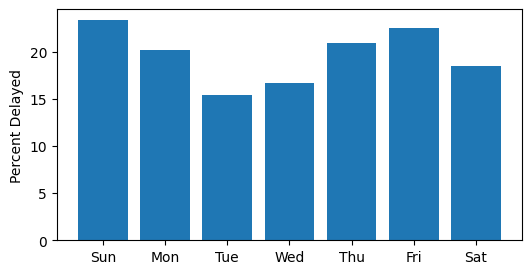

In [ ]:
plt.figure(figsize=(6, 3))
plt.bar(percent_delayed.index, percent_delayed)
plt.ylabel('Percent Delayed')
plt.show()

The day of the week with the fewest late flights is Tuesday.

## Project extensions

Below is a proposed extension idea. 

The file `us-daily-passengers.csv` contains data on the daily number of passengers flying in the United States throughout 2023.

Create a graph that shows the average number of passengers flying per day of the week. Then, compare this graph to your graph of the percentage of flights delayed by day of week. What patterns do you see?

In [ ]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'us-daily-passengers.csv'.

# from google.colab import files
# uploaded = files.upload()

In [ ]:
passengers = pd.read_csv('us-daily-passengers.csv')
passengers['date'] = pd.to_datetime(passengers['date'])
passengers['day_name'] = passengers['date'].dt.day_name()

passengers

/var/folders/3l/m5jc265s55bf344jgjb45h8w0000gn/T/ipykernel_7437/983920741.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  passengers['date'] = pd.to_datetime(passengers['date'])


,date,num_passengers,day_name
0,2023-01-01,2046950,Sunday
1,2023-01-02,2368194,Monday
2,2023-01-03,2212528,Tuesday
3,2023-01-04,1985965,Wednesday
4,2023-01-05,2031976,Thursday
...,...,...,...
360,2023-12-27,2663517,Wednesday
361,2023-12-28,2633264,Thursday
362,2023-12-29,2636605,Friday
363,2023-12-30,2563962,Saturday


In [67]:
new_index_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
passengers_by_day = passengers.groupby('day_name')['num_passengers'].mean().reindex(new_index_order)

passengers_by_day

day_name
Sunday       2.506567e+06
Monday       2.442001e+06
Tuesday      2.098239e+06
Wednesday    2.210753e+06
Thursday     2.489463e+06
Friday       2.547110e+06
Saturday     2.168205e+06
Name: num_passengers, dtype: float64

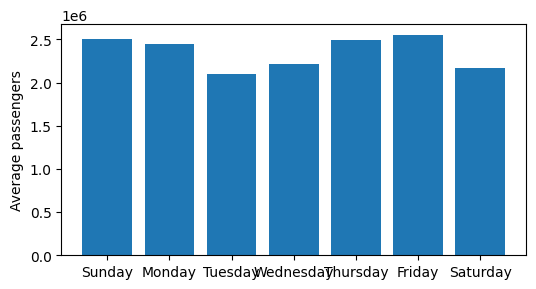

In [68]:
plt.figure(figsize=(6, 3))
plt.bar(passengers_by_day.index, passengers_by_day)
plt.ylabel('Average passengers')
plt.show()